# Modeling With processed_data

`processed_data` 폴더의 전처리 완료 CSV를 이용해 양품/불량 분류 모델을 학습하고 비교합니다.

사용 파일:
- `processed_data/df_final.csv`: 기본 전처리/파생변수 포함 데이터
- `processed_data/df_pad.csv`: pad 버전 데이터
- `processed_data/lr_cols.csv`: Logistic Regression용 컬럼 목록
- `processed_data/tree_cols.csv`: tree/boost 계열용 컬럼 목록
- `processed_data/tree_pad_cols.csv`: pad 데이터용 tree/boost 컬럼 목록

평가 지표:
- F1
- PR-AUC / Average Precision
- Precision, Recall
- ROC-AUC
- Balanced Accuracy

불량이 약 3%인 극심한 불균형 데이터이므로 accuracy보다 F1, PR-AUC, Recall/Precision 균형을 우선합니다.


In [35]:
import sys
print(sys.executable)
print(sys.version)

# 필요 패키지 예시:
# .venv/bin/pip install pandas numpy matplotlib seaborn scikit-learn joblib
# 선택 모델:
# .venv/bin/pip install imbalanced-learn xgboost lightgbm catboost pytorch-tabnet torch


/Users/yejinpark/Desktop/bigdata_project/.venv/bin/python
3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]


In [36]:
from pathlib import Path
import importlib.util
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix, classification_report, precision_recall_curve
)

sns.set_theme(style='whitegrid', font='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
DATA_DIR = ROOT / 'processed_data'
OUT_DIR = ROOT / 'outputs_processed' / 'modeling'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RUN_HEAVY_MODELS = False  # TabNet 등 시간이 오래 걸리는 모델은 True로 바꿔 실행하세요.
TARGET_COL = 'judge'


## 1. 데이터 로드

In [37]:
df_final = pd.read_csv(DATA_DIR / 'df_final.csv')
df_pad = pd.read_csv(DATA_DIR / 'df_pad.csv')
lr_cols = pd.read_csv(DATA_DIR / 'lr_cols.csv').iloc[:, 0].dropna().tolist()
tree_cols = pd.read_csv(DATA_DIR / 'tree_cols.csv').iloc[:, 0].dropna().tolist()
tree_pad_cols = pd.read_csv(DATA_DIR / 'tree_pad_cols.csv').iloc[:, 0].dropna().tolist()

print('df_final:', df_final.shape)
print('df_pad:', df_pad.shape)
print('lr_cols:', len(lr_cols))
print('tree_cols:', len(tree_cols))
print('tree_pad_cols:', len(tree_pad_cols))

assert TARGET_COL in df_final.columns
assert TARGET_COL in df_pad.columns
assert set(lr_cols).issubset(df_final.columns)
assert set(tree_cols).issubset(df_final.columns)
assert set(tree_pad_cols).issubset(df_pad.columns)

print(df_final[TARGET_COL].value_counts())
print(df_final[TARGET_COL].value_counts(normalize=True))
df_final.head()


df_final: (38595, 142)
df_pad: (38595, 141)
lr_cols: 64
tree_cols: 134
tree_pad_cols: 134
judge
0    37377
1     1218
Name: count, dtype: int64
judge
0    0.968442
1    0.031558
Name: proportion, dtype: float64


,lot_id,tray_id,cell_id,dt_start,judge,rta1_cell_no,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,...,date,weekday,ce1,ce2,c3_cc_ratio,c4_cc_ratio,m1_missing_flag,all_missing_flag,temp_mean,temp_bin
0,100,1023,10747,2025-09-01 10:01:25,0,10,8,33,8,3,...,2025-09-01,0,8.432801,87.040000,0.771696,0.950957,0,0,267.571429,"(263.543, 267.886]"
1,100,1023,10748,2025-09-01 10:01:25,0,7,8,33,8,3,...,2025-09-01,0,8.528951,82.800609,0.765625,0.952202,0,0,267.571429,"(263.543, 267.886]"
2,100,1023,10749,2025-09-01 10:01:25,0,19,8,33,8,3,...,2025-09-01,0,8.452455,86.349206,0.768924,0.950351,0,0,267.571429,"(263.543, 267.886]"
3,100,1023,10750,2025-09-01 10:01:25,0,24,8,33,8,3,...,2025-09-01,0,8.418289,86.762360,0.762092,0.950743,0,0,267.571429,"(263.543, 267.886]"
4,100,1023,10751,2025-09-01 10:01:25,0,17,8,33,8,3,...,2025-09-01,0,8.387296,88.743883,0.784447,0.953803,0,0,267.571429,"(263.543, 267.886]"


## 2. 모델 입력 세트 구성

이전 방식과 동일하게 LR용, tree/boost용, tree/boost pad용 입력을 따로 둡니다. 이미 processed_data에서 전처리가 되어 있지만, 모델 실행 안정성을 위해 결측/무한대는 median imputer로 한 번 더 처리합니다.

In [38]:
y = df_final[TARGET_COL].astype(int).copy()

X_lr_raw = df_final[lr_cols].replace([np.inf, -np.inf], np.nan).copy()
X_tree_raw = df_final[tree_cols].replace([np.inf, -np.inf], np.nan).copy()
X_tree_pad_raw = df_pad[tree_pad_cols].replace([np.inf, -np.inf], np.nan).copy()

for name, X in [('X_lr_raw', X_lr_raw), ('X_tree_raw', X_tree_raw), ('X_tree_pad_raw', X_tree_pad_raw)]:
    print(name, X.shape, 'missing:', int(X.isna().sum().sum()))

# 전체 데이터 기준 imputation은 기존 방식에 맞춘 처리입니다. feedback 버전처럼 split 이후 fit하지 않습니다.
def median_impute_frame(X):
    all_missing = X.columns[X.isna().all()].tolist()
    X2 = X.drop(columns=all_missing)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X2), columns=X2.columns, index=X2.index)
    return X_imp, all_missing, imputer

X_lr, lr_all_missing, lr_imputer = median_impute_frame(X_lr_raw)
X_tree, tree_all_missing, tree_imputer = median_impute_frame(X_tree_raw)
X_tree_pad, tree_pad_all_missing, tree_pad_imputer = median_impute_frame(X_tree_pad_raw)

print('after imputation')
print('X_lr:', X_lr.shape, 'dropped all-missing:', lr_all_missing)
print('X_tree:', X_tree.shape, 'dropped all-missing:', tree_all_missing)
print('X_tree_pad:', X_tree_pad.shape, 'dropped all-missing:', tree_pad_all_missing)


X_lr_raw (38595, 64) missing: 408
X_tree_raw (38595, 134) missing: 618
X_tree_pad_raw (38595, 134) missing: 0
after imputation
X_lr: (38595, 64) dropped all-missing: []
X_tree: (38595, 134) dropped all-missing: []
X_tree_pad: (38595, 134) dropped all-missing: []


## 3. Stratified Train / Valid / Test Split

In [39]:
idx_train_valid, idx_test = train_test_split(
    y.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
idx_train, idx_valid = train_test_split(
    idx_train_valid, test_size=0.25, stratify=y.loc[idx_train_valid], random_state=RANDOM_STATE
)

for name, idx in [('train', idx_train), ('valid', idx_valid), ('test', idx_test)]:
    print(name, 'rows=', len(idx), 'defects=', int(y.loc[idx].sum()), 'defect_rate=', y.loc[idx].mean())


train rows= 23157 defects= 731 defect_rate= 0.03156712872997366
valid rows= 7719 defects= 243 defect_rate= 0.03148076175670424
test rows= 7719 defects= 244 defect_rate= 0.03161031221660837


## 4. 평가 함수

In [40]:
def find_best_threshold(y_true, score):
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])

def get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X)
        return (s - np.nanmin(s)) / max(np.nanmax(s) - np.nanmin(s), 1e-12)
    return model.predict(X).astype(float)

def metric_row(name, y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    row = {
        'model': name,
        'threshold': threshold,
        'f1': f1_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, score),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'tn': cm[0, 0], 'fp': cm[0, 1], 'fn': cm[1, 0], 'tp': cm[1, 1],
    }
    try:
        row['roc_auc'] = roc_auc_score(y_true, score)
    except Exception:
        row['roc_auc'] = np.nan
    return row

def get_matrix(data_key):
    if data_key == 'lr':
        return X_lr
    if data_key == 'tree_pad':
        return X_tree_pad
    return X_tree

def evaluate_supervised(name, model, data_key):
    X = get_matrix(data_key)
    X_tr, y_tr = X.loc[idx_train], y.loc[idx_train]
    X_va, y_va = X.loc[idx_valid], y.loc[idx_valid]
    X_te, y_te = X.loc[idx_test], y.loc[idx_test]

    fitted = clone(model)
    fitted.fit(X_tr, y_tr)
    valid_score = get_scores(fitted, X_va)
    threshold = find_best_threshold(y_va, valid_score)
    test_score = get_scores(fitted, X_te)
    row = metric_row(name, y_te, test_score, threshold)
    return row, fitted, test_score

def evaluate_oneclass(name, model, data_key):
    X = get_matrix(data_key)
    y_tr = y.loc[idx_train]
    normal_idx = y_tr[y_tr == 0].index
    fitted = clone(model)
    fitted.fit(X.loc[normal_idx])

    valid_score = -fitted.decision_function(X.loc[idx_valid])
    threshold = find_best_threshold(y.loc[idx_valid], valid_score)
    test_score = -fitted.decision_function(X.loc[idx_test])
    row = metric_row(name, y.loc[idx_test], test_score, threshold)
    return row, fitted, test_score


## 5. 모델 Registry

설치되지 않은 외부 패키지는 자동으로 skip합니다.

In [41]:
def has_pkg(pkg):
    return importlib.util.find_spec(pkg) is not None

models = []
models.append(('Dummy_stratified', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE), 'tree', 'supervised'))
models.append(('LogisticRegression_balanced', Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=3000, solver='lbfgs', random_state=RANDOM_STATE))
]), 'lr', 'supervised'))
models.extend([
    ('DecisionTree_balanced', DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('RandomForest_balanced', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('RandomForest_balanced_pad', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree_pad', 'supervised'),
    ('ExtraTrees_balanced', ExtraTreesClassifier(n_estimators=400, class_weight='balanced', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('GradientBoosting', GradientBoostingClassifier(random_state=RANDOM_STATE), 'tree', 'supervised'),
])
models.append(('OneClassSVM_normal_only', Pipeline([
    ('scaler', StandardScaler()),
    ('clf', OneClassSVM(kernel='rbf', nu=0.035, gamma='scale'))
]), 'lr', 'oneclass'))

if has_pkg('imblearn'):
    from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier, EasyEnsembleClassifier
    models.extend([
        ('BalancedRandomForest', BalancedRandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1), 'tree', 'supervised'),
        ('RUSBoost', RUSBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE), 'tree', 'supervised'),
        ('EasyEnsemble', EasyEnsembleClassifier(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1), 'tree', 'supervised'),
    ])
else:
    print('skip imbalanced-learn models: imblearn not installed')

if has_pkg('xgboost'):
    from xgboost import XGBClassifier
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
    models.append(('XGBoost_weighted', XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
        objective='binary:logistic', eval_metric='aucpr', scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1
    ), 'tree', 'supervised'))
else:
    print('skip XGBoost: xgboost not installed')

if has_pkg('lightgbm'):
    from lightgbm import LGBMClassifier
    models.append(('LightGBM_balanced', LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=31, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    ), 'tree', 'supervised'))
else:
    print('skip LightGBM: lightgbm not installed')

if has_pkg('catboost'):
    from catboost import CatBoostClassifier
    models.append(('CatBoost_balanced', CatBoostClassifier(
        iterations=600, learning_rate=0.03, depth=5, loss_function='Logloss', eval_metric='PRAUC',
        auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False
    ), 'tree', 'supervised'))
else:
    print('skip CatBoost: catboost not installed')

if RUN_HEAVY_MODELS and has_pkg('pytorch_tabnet'):
    from pytorch_tabnet.tab_model import TabNetClassifier
    models.append(('TabNet', TabNetClassifier(seed=RANDOM_STATE, verbose=0), 'tree', 'supervised'))
elif not RUN_HEAVY_MODELS:
    print('skip TabNet: RUN_HEAVY_MODELS=False')

print('models to run:', [m[0] for m in models])


skip TabNet: RUN_HEAVY_MODELS=False
models to run: ['Dummy_stratified', 'LogisticRegression_balanced', 'DecisionTree_balanced', 'RandomForest_balanced', 'RandomForest_balanced_pad', 'ExtraTrees_balanced', 'GradientBoosting', 'OneClassSVM_normal_only', 'BalancedRandomForest', 'RUSBoost', 'EasyEnsemble', 'XGBoost_weighted', 'LightGBM_balanced', 'CatBoost_balanced']


## 6. 모델 학습 및 성능 비교

In [42]:
results = []
fitted_models = {}
test_scores = {}

for name, model, data_key, mode in models:
    print()
    print(f'=== {name} ===')
    try:
        if mode == 'oneclass':
            row, fitted, score = evaluate_oneclass(name, model, data_key)
        else:
            row, fitted, score = evaluate_supervised(name, model, data_key)
        row['data_key'] = data_key
        results.append(row)
        fitted_models[name] = fitted
        test_scores[name] = score
        print({k: row[k] for k in ['f1', 'precision', 'recall', 'pr_auc', 'threshold']})
    except Exception as e:
        print('FAILED:', repr(e))
        results.append({'model': name, 'data_key': data_key, 'status': f'failed: {e}'})

results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(['pr_auc', 'f1'], ascending=False, na_position='last')
display(results_sorted)
results_sorted.to_csv(OUT_DIR / 'processed_model_performance_comparison.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'processed_model_performance_comparison.csv')



=== Dummy_stratified ===
{'f1': 0.06128343589099586, 'precision': 0.03161031221660837, 'recall': 1.0, 'pr_auc': 0.0315765880065453, 'threshold': 0.0}

=== LogisticRegression_balanced ===
{'f1': 0.24671052631578946, 'precision': 0.20604395604395603, 'recall': 0.3073770491803279, 'pr_auc': 0.231589280562161, 'threshold': 0.8272554475542128}

=== DecisionTree_balanced ===
{'f1': 0.6794625719769674, 'precision': 0.6389891696750902, 'recall': 0.7254098360655737, 'pr_auc': 0.6257082868323033, 'threshold': 0.9568159739543675}

=== RandomForest_balanced ===
{'f1': 0.6695278969957081, 'precision': 0.7027027027027027, 'recall': 0.639344262295082, 'pr_auc': 0.7206135240610516, 'threshold': 0.5169372669642744}

=== RandomForest_balanced_pad ===
{'f1': 0.6695278969957081, 'precision': 0.7027027027027027, 'recall': 0.639344262295082, 'pr_auc': 0.7206135240610516, 'threshold': 0.5169372669642744}

=== ExtraTrees_balanced ===
{'f1': 0.5783664459161147, 'precision': 0.6267942583732058, 'recall': 0.536

,model,threshold,f1,precision,recall,pr_auc,balanced_accuracy,tn,fp,fn,tp,roc_auc,data_key
12,LightGBM_balanced,0.678267,0.758893,0.732824,0.786885,0.844296,0.888760,7405,70,52,192,0.989767,tree
11,XGBoost_weighted,0.814835,0.733212,0.657980,0.827869,0.752471,0.906911,7370,105,42,202,0.985601,tree
6,GradientBoosting,0.267872,0.756567,0.660550,0.885246,0.747515,0.935198,7364,111,28,216,0.978308,tree
13,CatBoost_balanced,0.905190,0.719844,0.685185,0.758197,0.733738,0.873413,7390,85,59,185,0.986540,tree
3,RandomForest_balanced,0.516937,0.669528,0.702703,0.639344,0.720614,0.815257,7409,66,88,156,0.982517,tree
4,RandomForest_balanced_pad,0.516937,0.669528,0.702703,0.639344,0.720614,0.815257,7409,66,88,156,0.982517,tree_pad
8,BalancedRandomForest,0.752500,0.628803,0.622490,0.635246,0.673729,0.811335,7381,94,89,155,0.977669,tree
2,DecisionTree_balanced,0.956816,0.679463,0.638989,0.725410,0.625708,0.856016,7375,100,67,177,0.932296,tree
5,ExtraTrees_balanced,0.692239,0.578366,0.626794,0.536885,0.584055,0.763225,7397,78,113,131,0.962883,tree
10,EasyEnsemble,0.555024,0.449438,0.369393,0.573770,0.340487,0.770899,7236,239,104,140,0.929297,tree


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/processed_model_performance_comparison.csv


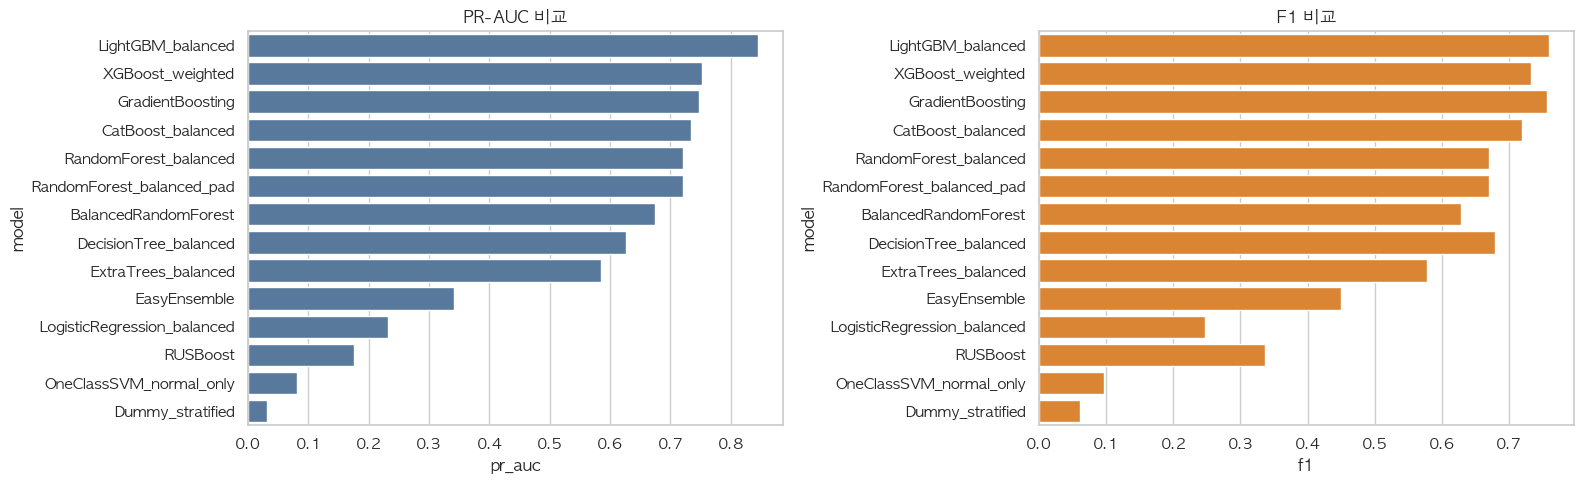

In [43]:
plot_df = results_sorted.dropna(subset=['f1', 'pr_auc']).copy()
if len(plot_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=plot_df, y='model', x='pr_auc', ax=axes[0], color='#4C78A8')
    axes[0].set_title('PR-AUC 비교')
    sns.barplot(data=plot_df, y='model', x='f1', ax=axes[1], color='#F58518')
    axes[1].set_title('F1 비교')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_model_metric_comparison.png', dpi=150)
    plt.show()


### 6-1. 모델별 설명변수 중요도 시각화

성능 비교 대상 모델별로 feature importance 또는 coefficient 기반 설명변수 그래프를 저장합니다.


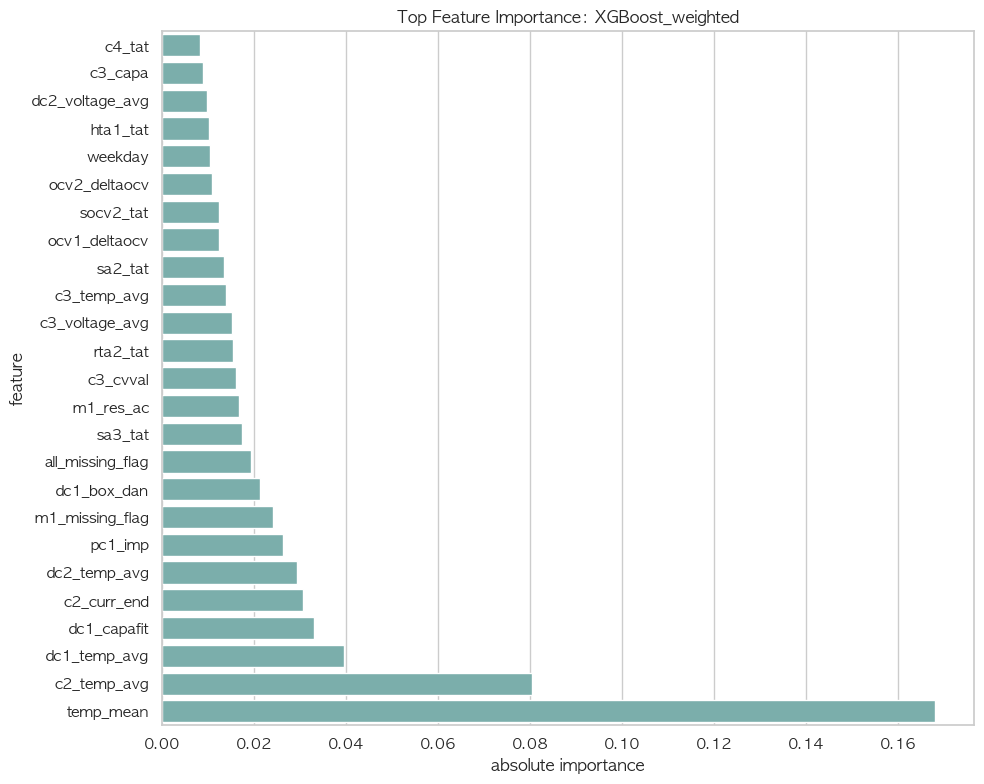

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/XGBoost_weighted_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/XGBoost_weighted_feature_importance.png


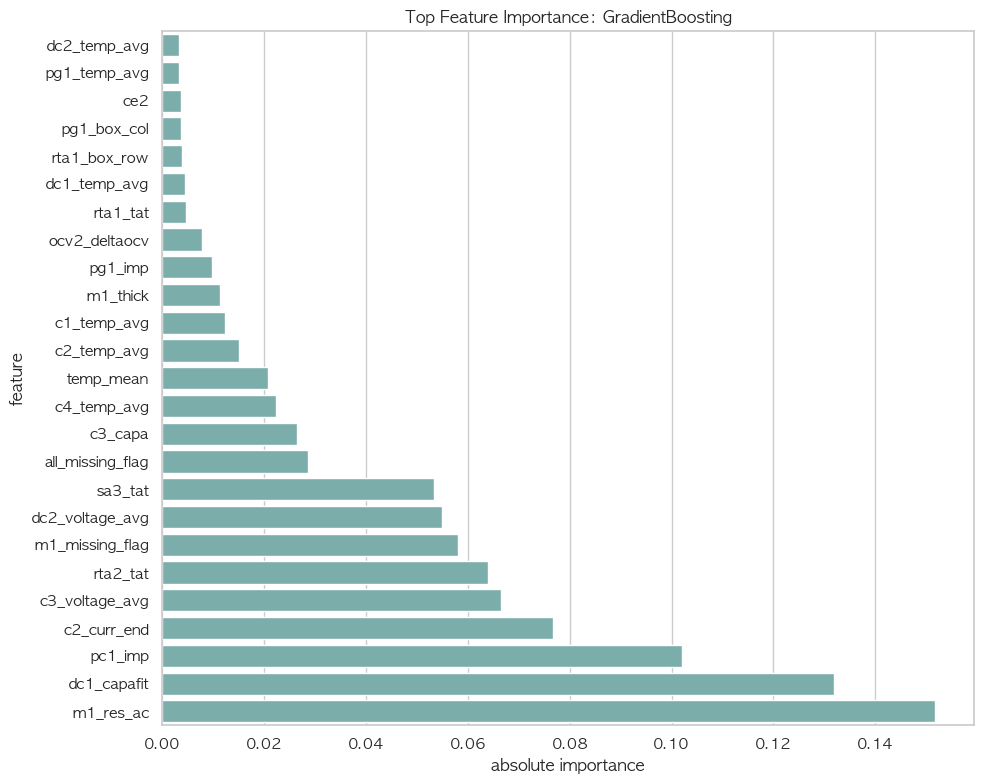

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/GradientBoosting_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/GradientBoosting_feature_importance.png


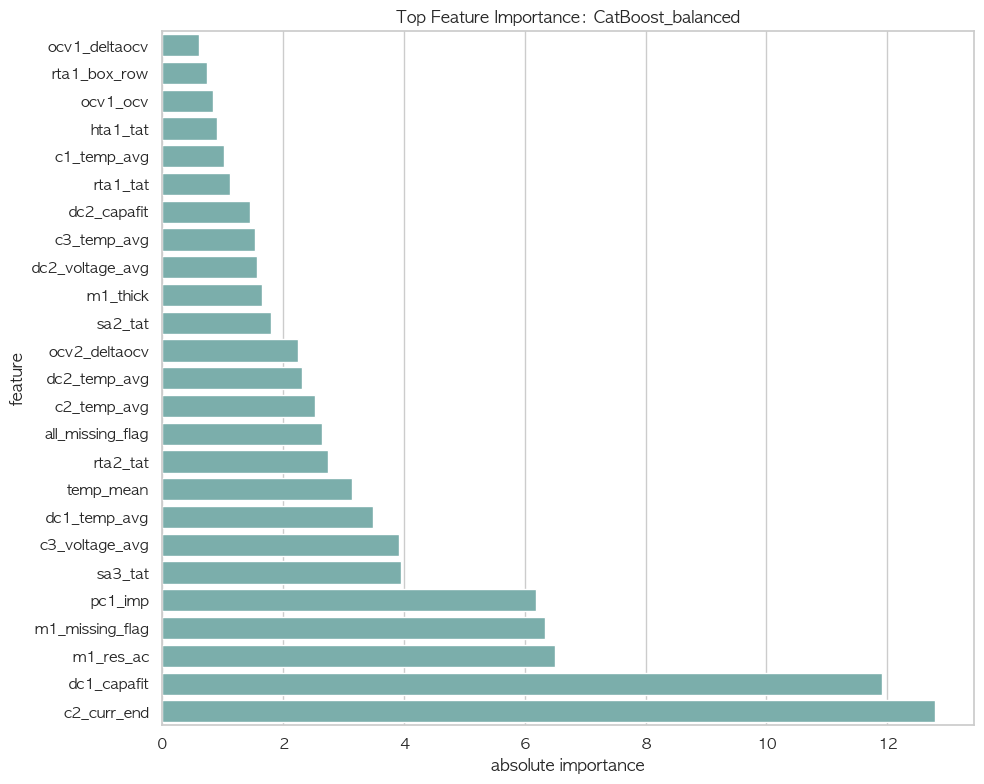

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/CatBoost_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/CatBoost_balanced_feature_importance.png


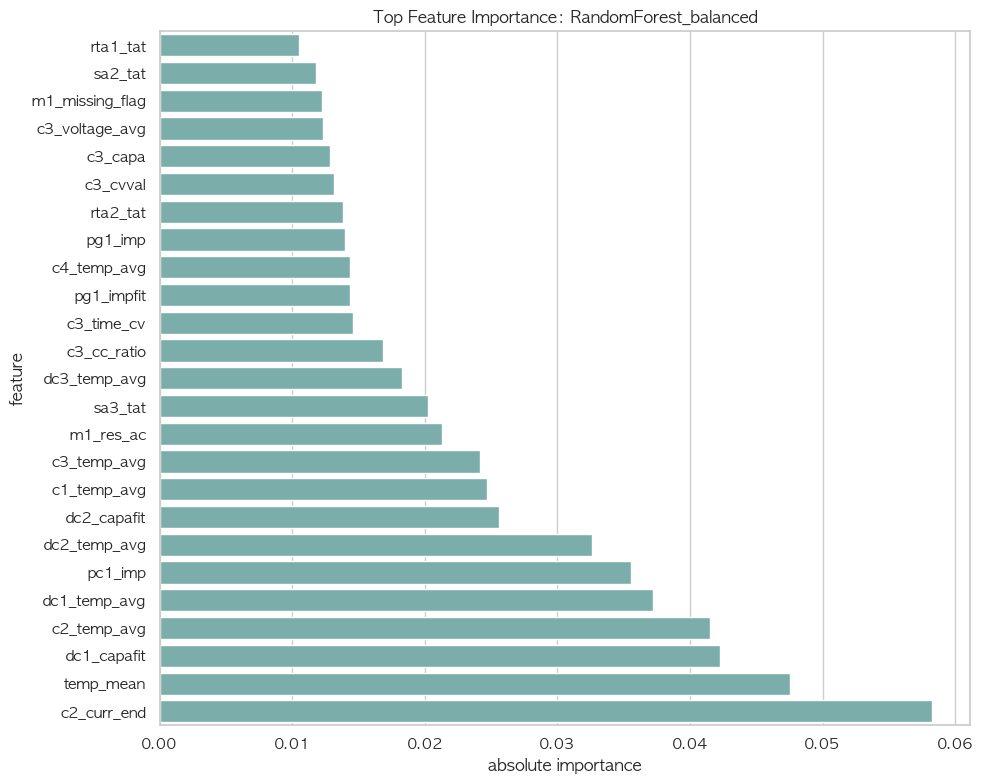

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RandomForest_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RandomForest_balanced_feature_importance.png


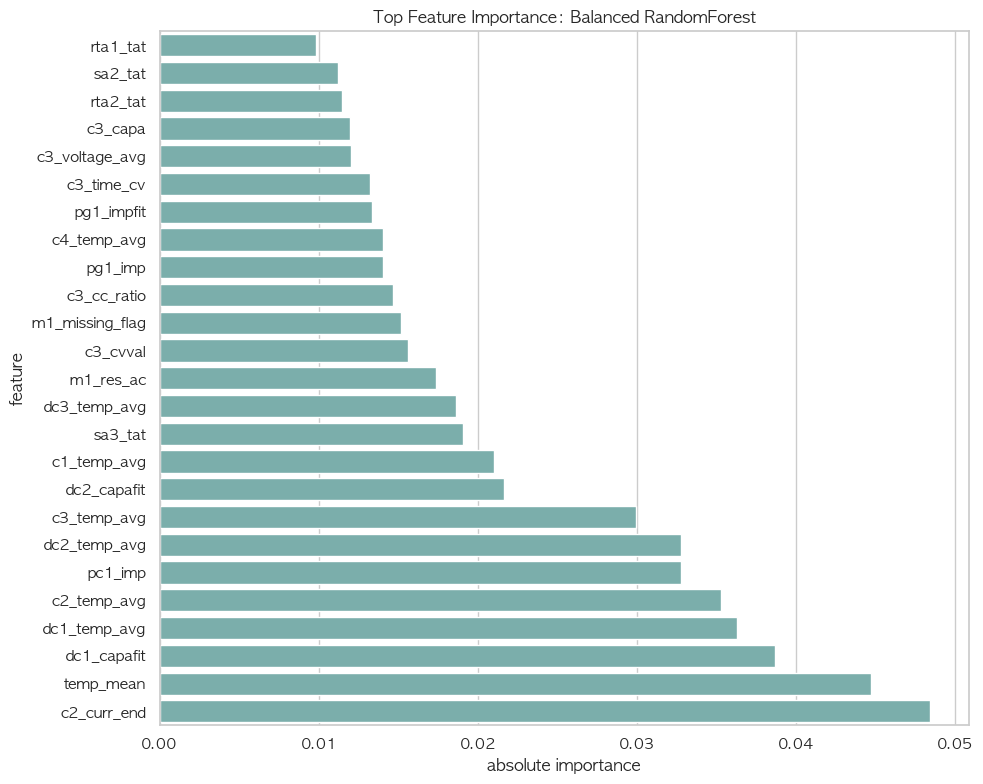

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/Balanced_RandomForest_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/Balanced_RandomForest_feature_importance.png


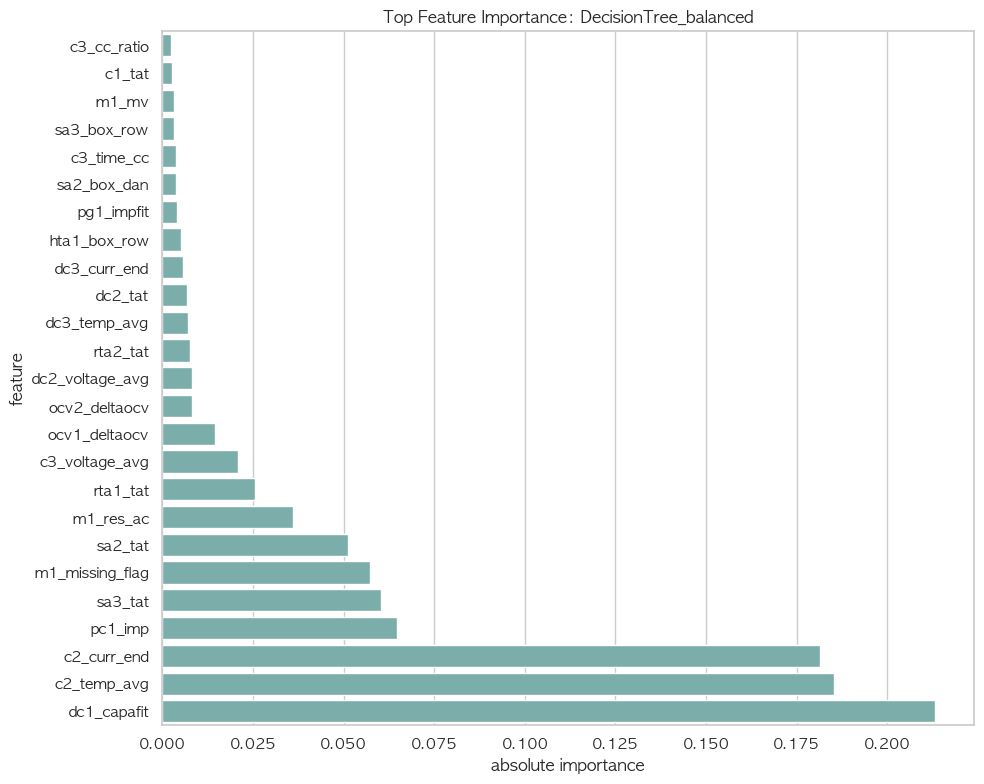

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/DecisionTree_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/DecisionTree_balanced_feature_importance.png


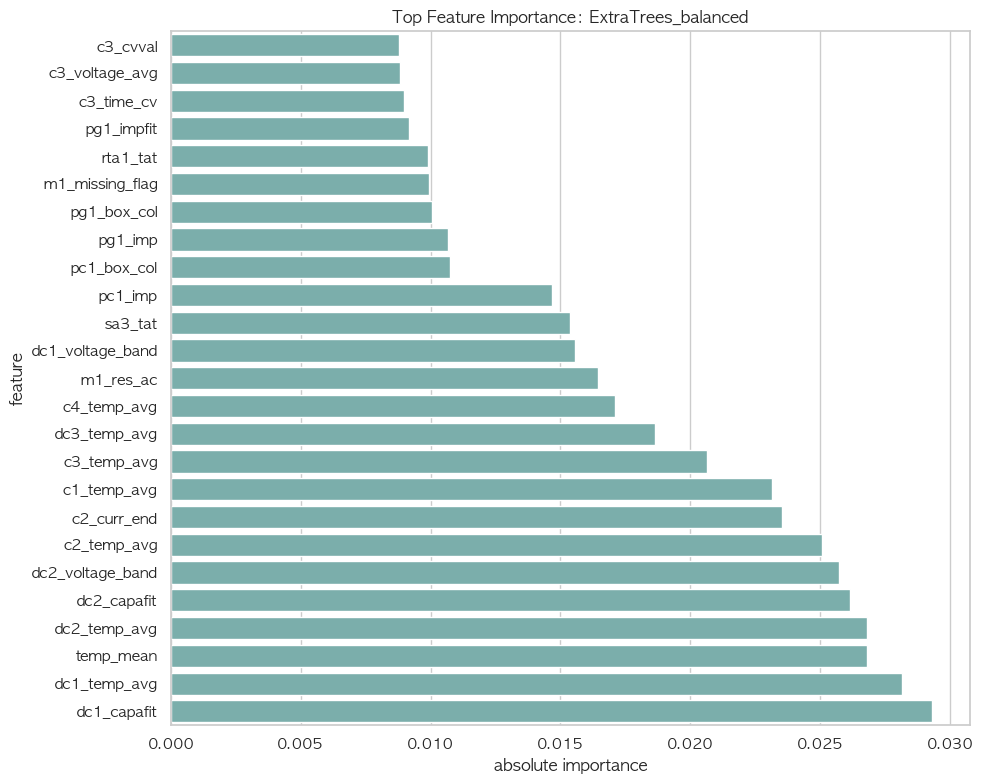

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/ExtraTrees_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/ExtraTrees_balanced_feature_importance.png


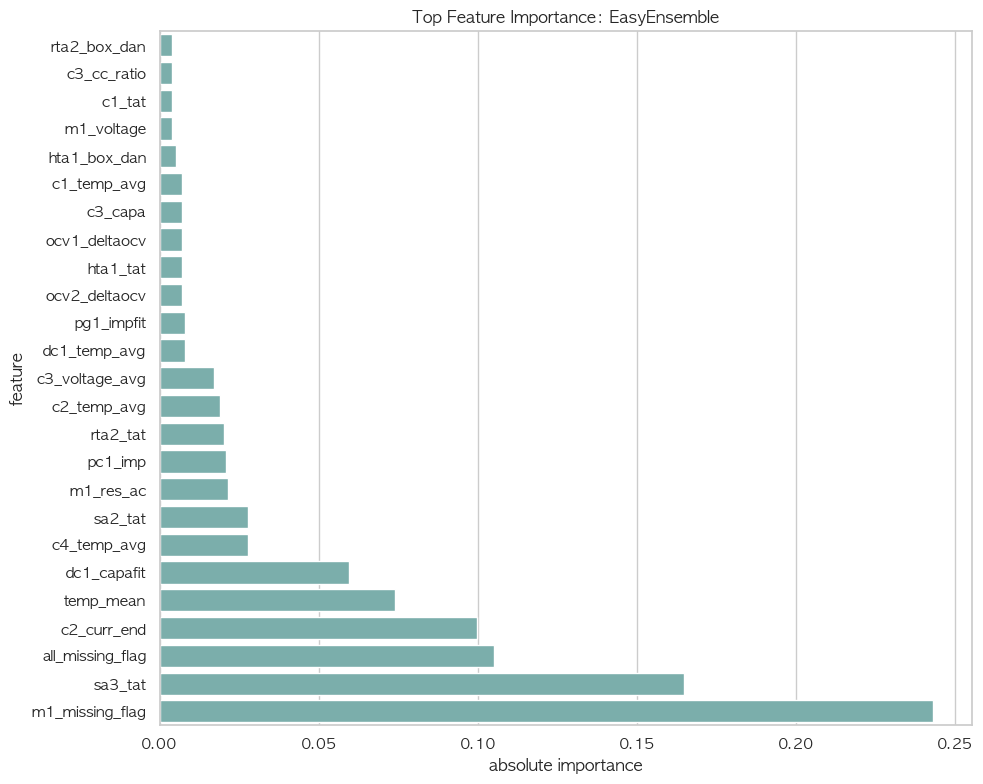

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/EasyEnsemble_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/EasyEnsemble_feature_importance.png


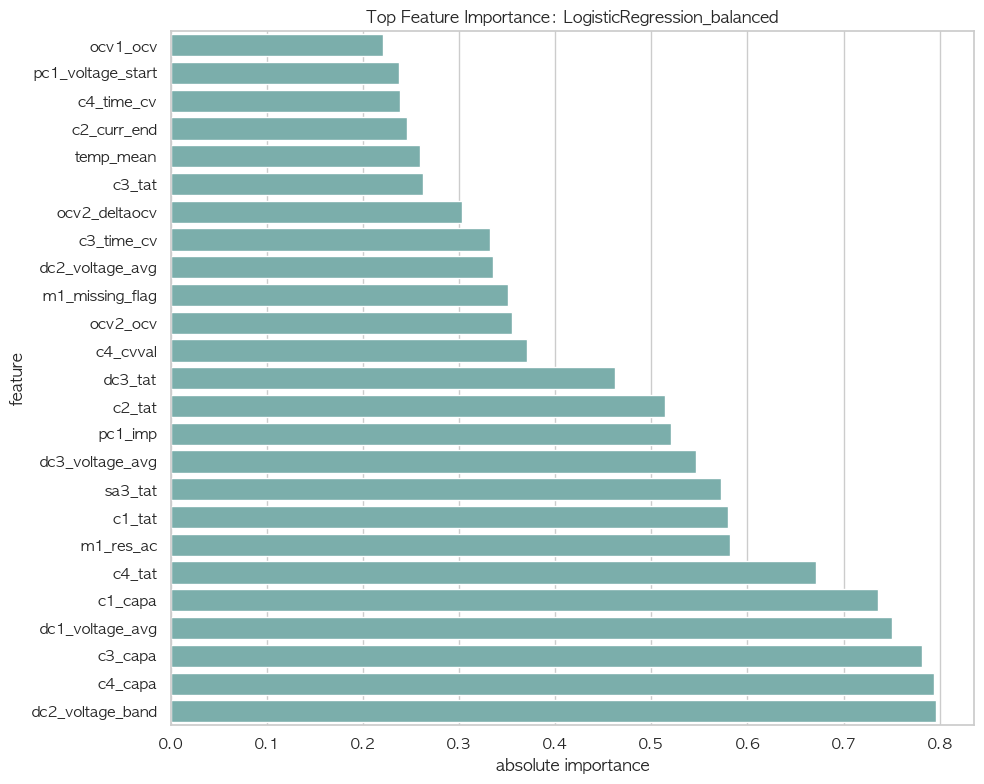

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/LogisticRegression_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/LogisticRegression_balanced_feature_importance.png


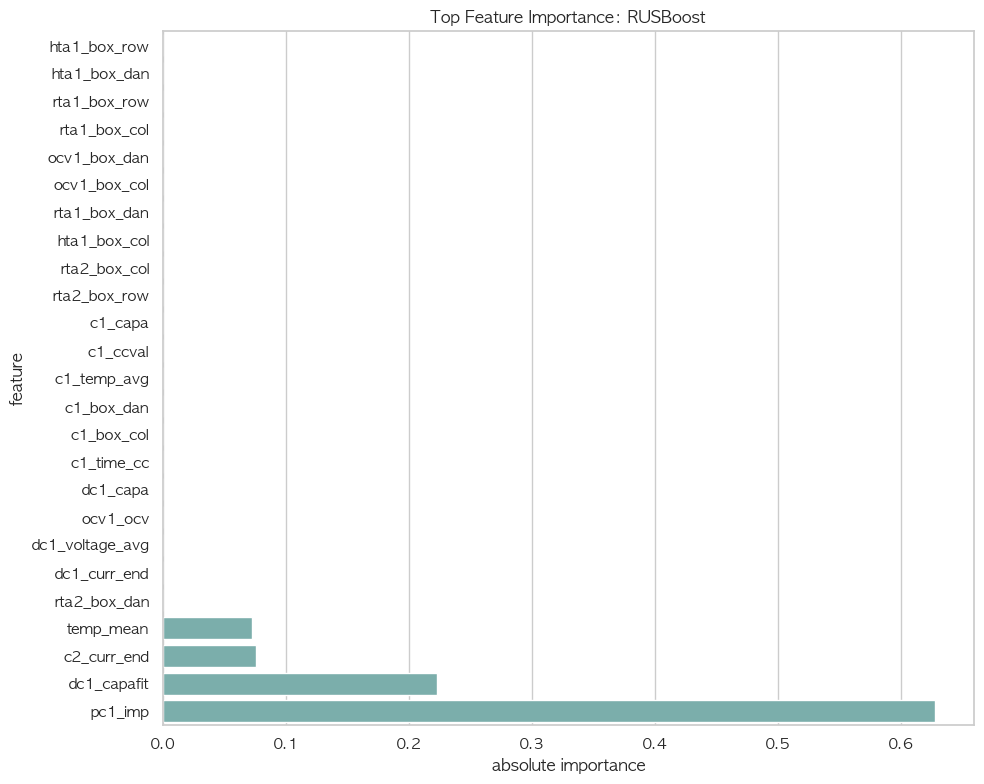

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RUSBoost_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RUSBoost_feature_importance.png


,model,data_key,feature,importance,abs_importance
0,XGBoost_weighted,tree,temp_mean,0.168062,0.168062
1,XGBoost_weighted,tree,c2_temp_avg,0.080460,0.080460
2,XGBoost_weighted,tree,dc1_temp_avg,0.039547,0.039547
3,XGBoost_weighted,tree,dc1_capafit,0.032966,0.032966
4,XGBoost_weighted,tree,c2_curr_end,0.030670,0.030670
...,...,...,...,...,...
1141,RUSBoost,tree,rta1_box_row,0.000000,0.000000
1142,RUSBoost,tree,hta1_box_dan,0.000000,0.000000
1143,RUSBoost,tree,hta1_box_row,0.000000,0.000000
1144,RUSBoost,tree,hta1_box_col,0.000000,0.000000


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/all_model_feature_importance.csv


In [44]:
MODEL_NAMES_FOR_IMPORTANCE = [
    'XGBoost_weighted',
    'GradientBoosting',
    'CatBoost_balanced',
    'RandomForest_balanced',
    'Balanced RandomForest',
    'DecisionTree_balanced',
    'ExtraTrees_balanced',
    'EasyEnsemble',
    'LogisticRegression_balanced',
    'RUSBoost',
]

MODEL_NAME_ALIASES = {
    'Balanced RandomForest': 'BalancedRandomForest',
}

def _unwrap_estimator(model):
    if hasattr(model, 'named_steps'):
        return list(model.named_steps.values())[-1]
    return model

def _collect_importance_arrays(model):
    estimator = _unwrap_estimator(model)
    arrays = []

    if hasattr(estimator, 'feature_importances_'):
        arrays.append(np.asarray(estimator.feature_importances_, dtype=float))
    elif hasattr(estimator, 'coef_'):
        coef = np.asarray(estimator.coef_, dtype=float)
        if coef.ndim == 1:
            arrays.append(np.abs(coef))
        else:
            arrays.append(np.mean(np.abs(coef), axis=0))

    if hasattr(estimator, 'estimators_'):
        for sub_estimator in estimator.estimators_:
            arrays.extend(_collect_importance_arrays(sub_estimator))

    return arrays

def get_model_importance(model, feature_names):
    arrays = _collect_importance_arrays(model)
    valid_arrays = [arr for arr in arrays if len(arr) == len(feature_names)]
    if not valid_arrays:
        return None

    importance_values = np.mean(np.vstack(valid_arrays), axis=0)
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values,
    })
    importance['abs_importance'] = importance['importance'].abs()
    return importance.sort_values('abs_importance', ascending=False)

def _safe_filename(name):
    return (str(name)
            .replace(' ', '_')
            .replace('/', '_')
            .replace('\\', '_')
            .replace(':', '_'))

all_importance_rows = []

for display_name in MODEL_NAMES_FOR_IMPORTANCE:
    model_name = MODEL_NAME_ALIASES.get(display_name, display_name)
    if model_name not in fitted_models:
        print(f'skip {display_name}: fitted_models에 학습 모델이 없습니다.')
        continue

    model_rows = results_df[results_df['model'] == model_name].dropna(subset=['data_key'])
    if len(model_rows) == 0:
        print(f'skip {display_name}: data_key 정보를 찾을 수 없습니다.')
        continue

    data_key = model_rows.iloc[0]['data_key']
    X_used = get_matrix(data_key)
    importance = get_model_importance(fitted_models[model_name], X_used.columns)

    if importance is None:
        print(f'skip {display_name}: feature_importances_ 또는 coef_를 추출할 수 없습니다.')
        continue

    importance.insert(0, 'model', display_name)
    importance.insert(1, 'data_key', data_key)
    all_importance_rows.append(importance)

    safe_name = _safe_filename(display_name)
    importance_path = OUT_DIR / f'{safe_name}_importance.csv'
    plot_path = OUT_DIR / f'{safe_name}_feature_importance.png'

    importance.to_csv(importance_path, index=False, encoding='utf-8-sig')

    top_imp = importance.head(25).sort_values('abs_importance')
    fig_height = max(6, 0.32 * len(top_imp))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(data=top_imp, x='abs_importance', y='feature', ax=ax, color='#72B7B2')
    ax.set_title(f'Top Feature Importance: {display_name}')
    ax.set_xlabel('absolute importance')
    ax.set_ylabel('feature')
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    plt.show()

    print('saved:', importance_path)
    print('saved:', plot_path)

if all_importance_rows:
    all_model_importance = pd.concat(all_importance_rows, ignore_index=True)
    all_model_importance.to_csv(OUT_DIR / 'all_model_feature_importance.csv', index=False, encoding='utf-8-sig')
    display(all_model_importance.groupby('model').head(10))
    print('saved:', OUT_DIR / 'all_model_feature_importance.csv')


## 7. Best Model 상세 확인

Excluded from automatic best selection: ['LightGBM']
Best model after exclusion: XGBoost_weighted
Data key: tree
Threshold: 0.8148353099822998
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      7475
          불량       0.66      0.83      0.73       244

    accuracy                           0.98      7719
   macro avg       0.83      0.91      0.86      7719
weighted avg       0.98      0.98      0.98      7719



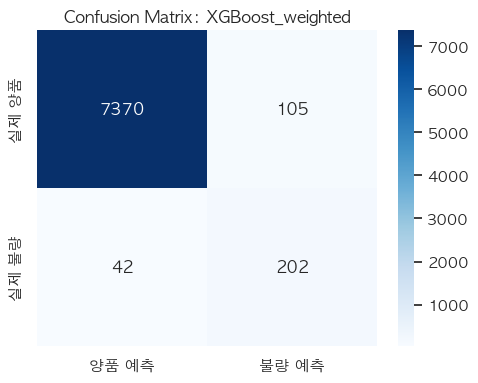

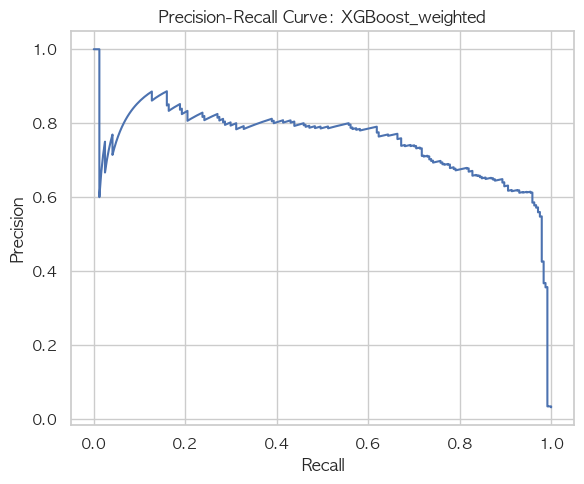

In [45]:
EXCLUDED_BEST_MODEL_PATTERNS = ['LightGBM']

valid_results = results_sorted.dropna(subset=['pr_auc', 'f1']).copy()
if len(valid_results):
    exclude_mask = valid_results['model'].astype(str).str.contains('|'.join(EXCLUDED_BEST_MODEL_PATTERNS), case=False, regex=True)
    best_candidate_results = valid_results[~exclude_mask].copy()

    if len(best_candidate_results) == 0:
        raise ValueError('LightGBM 제외 후 Best 후보 모델이 없습니다.')

    best_name = best_candidate_results.iloc[0]['model']
    best_threshold = float(best_candidate_results.iloc[0]['threshold'])
    best_score = test_scores[best_name]
    y_test = y.loc[idx_test]
    y_pred = (best_score >= best_threshold).astype(int)

    print('Excluded from automatic best selection:', EXCLUDED_BEST_MODEL_PATTERNS)
    print('Best model after exclusion:', best_name)
    print('Data key:', best_candidate_results.iloc[0].get('data_key'))
    print('Threshold:', best_threshold)
    print(classification_report(y_test, y_pred, target_names=['양품', '불량'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['양품 예측','불량 예측'], yticklabels=['실제 양품','실제 불량'], ax=ax)
    ax.set_title(f'Confusion Matrix: {best_name}')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_best_model_confusion_matrix.png', dpi=150)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, best_score)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve: {best_name}')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_best_model_pr_curve.png', dpi=150)
    plt.show()


## 8. Feature Importance / Coefficient

,feature,importance,abs_importance
133,temp_mean,0.168062,0.168062
34,c2_temp_avg,0.080460,0.080460
25,dc1_temp_avg,0.039547,0.039547
26,dc1_capafit,0.032966,0.032966
27,c2_curr_end,0.030670,0.030670
40,dc2_temp_avg,0.029236,0.029236
79,pc1_imp,0.026153,0.026153
131,m1_missing_flag,0.024021,0.024021
24,dc1_box_dan,0.021252,0.021252
132,all_missing_flag,0.019293,0.019293


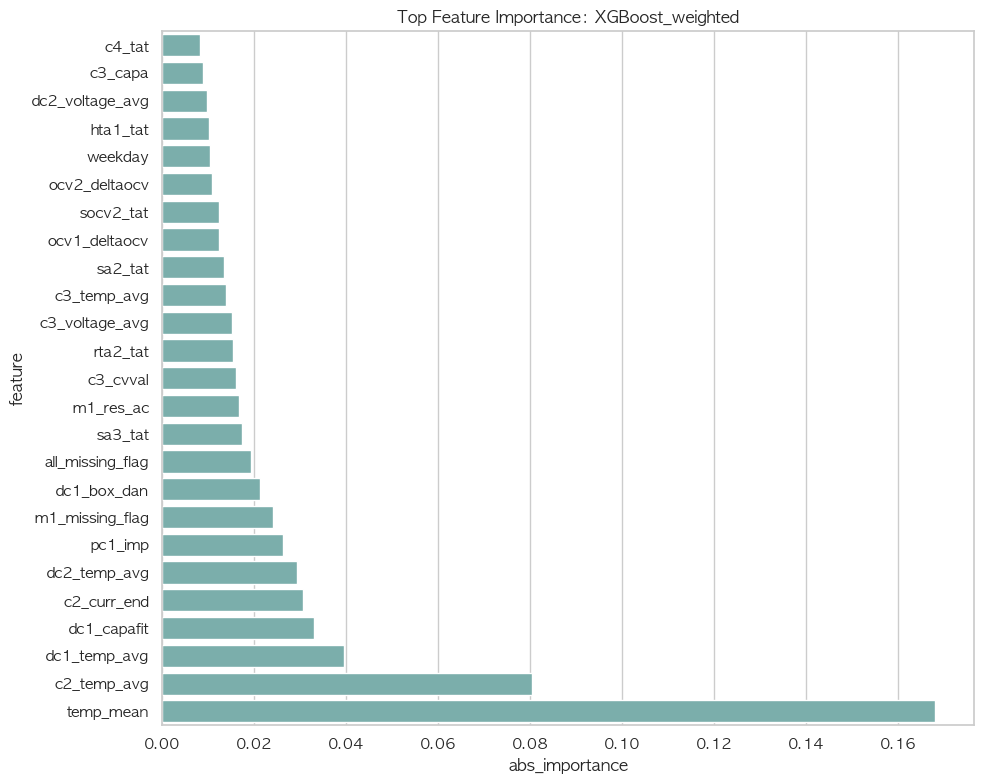

In [46]:
if len(valid_results):
    model = fitted_models[best_name]
    data_key = valid_results.iloc[0].get('data_key')
    X_used = get_matrix(data_key)
    feature_names = X_used.columns

    estimator = model.named_steps.get('clf', model) if hasattr(model, 'named_steps') else model
    importance = None
    if hasattr(estimator, 'feature_importances_'):
        importance = pd.DataFrame({'feature': feature_names, 'importance': estimator.feature_importances_})
    elif hasattr(estimator, 'coef_'):
        importance = pd.DataFrame({'feature': feature_names, 'importance': np.ravel(estimator.coef_)})

    if importance is not None:
        importance['abs_importance'] = importance['importance'].abs()
        importance = importance.sort_values('abs_importance', ascending=False)
        display(importance.head(30))
        importance.to_csv(OUT_DIR / f'{best_name}_importance.csv', index=False, encoding='utf-8-sig')

        fig, ax = plt.subplots(figsize=(10, 8))
        top_imp = importance.head(25).sort_values('abs_importance')
        sns.barplot(data=top_imp, x='abs_importance', y='feature', ax=ax, color='#72B7B2')
        ax.set_title(f'Top Feature Importance: {best_name}')
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'processed_best_model_feature_importance.png', dpi=150)
        plt.show()
    else:
        print('선택된 best model은 importance/coefficient를 직접 제공하지 않습니다.')


## 9. Threshold Sensitivity

운영 목적에 맞게 Recall을 더 높이고 싶을 때 Precision/False Positive 변화를 확인하기 위한 표입니다.

In [47]:
if len(valid_results):
    y_test = y.loc[idx_test]
    threshold_grid = np.quantile(best_score, np.linspace(0.50, 0.99, 15))
    threshold_rows = []
    for th in sorted(set(threshold_grid)):
        threshold_rows.append(metric_row(best_name, y_test, best_score, float(th)))
    threshold_df = pd.DataFrame(threshold_rows).sort_values('threshold')
    display(threshold_df[['threshold', 'f1', 'precision', 'recall', 'pr_auc', 'fp', 'fn', 'tp', 'tn']])
    threshold_df.to_csv(OUT_DIR / 'processed_threshold_sensitivity.csv', index=False, encoding='utf-8-sig')


,threshold,f1,precision,recall,pr_auc,fp,fn,tp,tn
0,0.012902,0.117934,0.062694,0.991803,0.752471,3618,2,242,3857
1,0.014246,0.126272,0.067428,0.991803,0.752471,3347,2,242,4128
2,0.015701,0.135841,0.072914,0.991803,0.752471,3077,2,242,4398
3,0.017459,0.146978,0.079370,0.991803,0.752471,2807,2,242,4668
4,0.019370,0.160106,0.087082,0.991803,0.752471,2537,2,242,4938
5,0.022264,0.175808,0.096453,0.991803,0.752471,2267,2,242,5208
6,0.024960,0.194925,0.108084,0.991803,0.752471,1997,2,242,5478
7,0.028772,0.218708,0.122905,0.991803,0.752471,1727,2,242,5748
8,0.034436,0.249228,0.142521,0.991803,0.752471,1456,2,242,6019
9,0.042362,0.289474,0.169468,0.991803,0.752471,1186,2,242,6289


## 10. XGBoost Hyperparameter Optimization

최종 모델 후보를 XGBoost로 두고, 기존 `XGBoost_weighted` 수동 설정을 0번 후보로 포함한 뒤 validation PR-AUC/F1 기준으로 최적 조합을 선택합니다.


In [48]:
# XGBoost GridSearchCV 튜닝 설정
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import make_scorer

if not has_pkg('xgboost'):
    raise ImportError('xgboost가 설치되어 있지 않습니다. .venv/bin/pip install xgboost 후 다시 실행하세요.')

from xgboost import XGBClassifier

X_xgb = X_tree
X_train_xgb, y_train_xgb = X_xgb.loc[idx_train], y.loc[idx_train]
X_valid_xgb, y_valid_xgb = X_xgb.loc[idx_valid], y.loc[idx_valid]
X_test_xgb, y_test_xgb = X_xgb.loc[idx_test], y.loc[idx_test]

xgb_scale_pos_weight = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

manual_xgb_params = {
    'n_estimators': 500,
    'max_depth': 4,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.0,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'scale_pos_weight': xgb_scale_pos_weight,
}

# 0번 후보: 기존 XGBoost_weighted 수동 설정
manual_xgb_grid = {key: [value] for key, value in manual_xgb_params.items()}

# GridSearchCV 후보군입니다.
# 실행 시간을 줄이기 위해 n_estimators, max_depth, learning_rate 중심으로 탐색합니다.
# 후보 수: manual baseline 1개 + grid 256개 = 총 257개
xgb_param_distributions = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'min_child_weight': [1],
    'gamma': [0.0],
    'reg_alpha': [0.0],
    'reg_lambda': [1.0],
    'scale_pos_weight': [xgb_scale_pos_weight],
}

xgb_param_grid = [manual_xgb_grid, xgb_param_distributions]

# 기존 train/valid split을 GridSearchCV에 그대로 전달합니다.
X_grid_xgb = pd.concat([X_train_xgb, X_valid_xgb], axis=0)
y_grid_xgb = pd.concat([y_train_xgb, y_valid_xgb], axis=0)
xgb_valid_fold = np.r_[
    np.full(len(X_train_xgb), -1),
    np.zeros(len(X_valid_xgb), dtype=int),
]
xgb_cv = PredefinedSplit(xgb_valid_fold)

print('XGBoost GridSearchCV candidates including manual baseline:', 1 + np.prod([len(v) for v in xgb_param_distributions.values()]))
print('candidate 000 is manual XGBoost_weighted baseline')
print('scale_pos_weight baseline:', xgb_scale_pos_weight)
print('train:', X_train_xgb.shape, 'valid:', X_valid_xgb.shape, 'test:', X_test_xgb.shape)


XGBoost GridSearchCV candidates including manual baseline: 257
candidate 000 is manual XGBoost_weighted baseline
scale_pos_weight baseline: 30.678522571819425
train: (23157, 134) valid: (7719, 134) test: (7719, 134)


In [49]:
# XGBoost GridSearchCV 실행 및 validation 평가 결과 정리
base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)

xgb_scoring = {
    'pr_auc': 'average_precision',
    'f1': make_scorer(f1_score, zero_division=0),
}

def refit_by_pr_auc_then_f1(cv_results):
    pr_auc = np.asarray(cv_results['mean_test_pr_auc'], dtype=float)
    f1 = np.asarray(cv_results['mean_test_f1'], dtype=float)
    best_pr_auc = np.nanmax(pr_auc)
    tied = np.flatnonzero(pr_auc == best_pr_auc)
    if len(tied) == 1:
        return int(tied[0])
    return int(tied[np.nanargmax(f1[tied])])

xgb_grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=xgb_param_grid,
    scoring=xgb_scoring,
    refit=refit_by_pr_auc_then_f1,
    cv=xgb_cv,
    n_jobs=1,  # XGBClassifier 내부 n_jobs=-1과 중첩 병렬화를 피합니다.
    verbose=2,
    return_train_score=False,
    error_score=np.nan,
)

xgb_grid_search.fit(X_grid_xgb, y_grid_xgb)

xgb_cv_results = pd.DataFrame(xgb_grid_search.cv_results_).copy()
xgb_tuning_results = pd.DataFrame(list(xgb_cv_results['params']))
xgb_tuning_results.insert(0, 'model', [
    'XGBoost_manual_baseline' if i == 0 else f'XGBoost_grid_{i:03d}'
    for i in range(len(xgb_tuning_results))
])
xgb_tuning_results.insert(1, 'candidate_id', np.arange(len(xgb_tuning_results)))
xgb_tuning_results.insert(2, 'is_manual_baseline', xgb_tuning_results['candidate_id'].eq(0))
xgb_tuning_results['valid_pr_auc'] = xgb_cv_results['mean_test_pr_auc']
xgb_tuning_results['valid_f1'] = xgb_cv_results['mean_test_f1']
xgb_tuning_results['rank_valid_pr_auc'] = xgb_cv_results['rank_test_pr_auc']
xgb_tuning_results['rank_valid_f1'] = xgb_cv_results['rank_test_f1']

xgb_tuning_results = xgb_tuning_results.sort_values(
    ['valid_pr_auc', 'valid_f1'],
    ascending=False,
    na_position='last',
).reset_index(drop=True)

display(xgb_tuning_results.head(20))

manual_xgb_result = xgb_tuning_results[xgb_tuning_results['is_manual_baseline']]
if len(manual_xgb_result):
    print('Manual XGBoost baseline rank:', int(manual_xgb_result.index[0] + 1), '/', len(xgb_tuning_results))
    display(manual_xgb_result.T)

xgb_tuning_results.to_csv(OUT_DIR / 'xgboost_tuning_results.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuning_results.csv')


Fitting 1 folds for each of 257 candidates, totalling 257 fits
[CV] END colsample_bytree=0.8, gamma=0.0, learning_rate=0.03, max_depth=4, min_child_weight=1, n_estimators=500, reg_alpha=0.0, reg_lambda=1.0, scale_pos_weight=30.678522571819425, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.8, gamma=0.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, reg_alpha=0.0, reg_lambda=1.0, scale_pos_weight=30.678522571819425, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, reg_alpha=0.0, reg_lambda=1.0, scale_pos_weight=30.678522571819425, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.8, gamma=0.0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, reg_alpha=0.0, reg_lambda=1.0, scale_pos_weight=30.678522571819425, subsample=0.8; total time=   2.0s
[CV] END colsample_bytree=0.8, gamma=0.0, learning_rate=0.01, max_depth=3, mi

,model,candidate_id,is_manual_baseline,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,scale_pos_weight,subsample,valid_pr_auc,valid_f1,rank_valid_pr_auc,rank_valid_f1
0,XGBoost_grid_095,95,False,0.8,0.0,0.03,6,1,1000,0.0,1.0,30.678523,0.8,0.816783,0.761905,1,75
1,XGBoost_grid_126,126,False,0.8,0.0,0.05,6,1,700,0.0,1.0,30.678523,0.9,0.815493,0.778420,2,15
2,XGBoost_grid_128,128,False,0.8,0.0,0.05,6,1,1000,0.0,1.0,30.678523,0.9,0.814378,0.773176,3,32
3,XGBoost_grid_224,224,False,0.9,0.0,0.03,6,1,1000,0.0,1.0,30.678523,0.9,0.814302,0.775281,4,22
4,XGBoost_grid_254,254,False,0.9,0.0,0.05,6,1,700,0.0,1.0,30.678523,0.9,0.813540,0.785441,5,4
5,XGBoost_grid_124,124,False,0.8,0.0,0.05,6,1,500,0.0,1.0,30.678523,0.9,0.812760,0.787313,6,2
6,XGBoost_grid_256,256,False,0.9,0.0,0.05,6,1,1000,0.0,1.0,30.678523,0.9,0.812706,0.777120,7,17
7,XGBoost_grid_125,125,False,0.8,0.0,0.05,6,1,700,0.0,1.0,30.678523,0.8,0.812322,0.779468,8,11
8,XGBoost_grid_127,127,False,0.8,0.0,0.05,6,1,1000,0.0,1.0,30.678523,0.8,0.812113,0.763209,9,70
9,XGBoost_grid_093,93,False,0.8,0.0,0.03,6,1,700,0.0,1.0,30.678523,0.8,0.810097,0.767273,10,59


Manual XGBoost baseline rank: 137 / 257


,136
model,XGBoost_manual_baseline
candidate_id,0
is_manual_baseline,True
colsample_bytree,0.8
gamma,0.0
learning_rate,0.03
max_depth,4
min_child_weight,1
n_estimators,500
reg_alpha,0.0


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuning_results.csv


Best GridSearchCV candidate index: 95
Best XGBoost candidate name: XGBoost_grid_095
Best validation threshold: 0.41011497378349304


,best_candidate
model,XGBoost_grid_095
candidate_id,95
is_manual_baseline,False
colsample_bytree,0.8
gamma,0.0
learning_rate,0.03
max_depth,6
min_child_weight,1
n_estimators,1000
reg_alpha,0.0


,model,threshold,f1,precision,recall,pr_auc,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,XGBoost_tuned_best,0.410115,0.772128,0.714286,0.840164,0.818025,0.914597,7393,82,39,205,0.989265


Best XGBoost params:
colsample_bytree: 0.8
gamma: 0.0
learning_rate: 0.03
max_depth: 6
min_child_weight: 1
n_estimators: 1000
reg_alpha: 0.0
reg_lambda: 1.0
scale_pos_weight: 30.678522571819425
subsample: 0.8
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_test_report.csv
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      7475
          불량       0.71      0.84      0.77       244

    accuracy                           0.98      7719
   macro avg       0.85      0.91      0.88      7719
weighted avg       0.99      0.98      0.98      7719



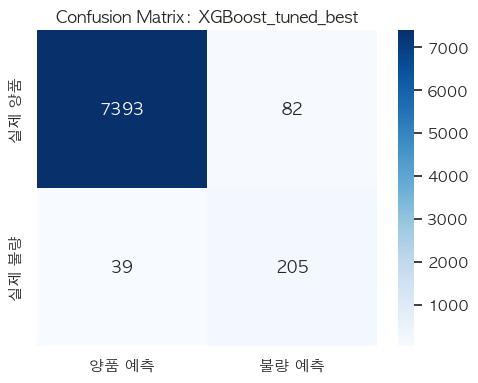

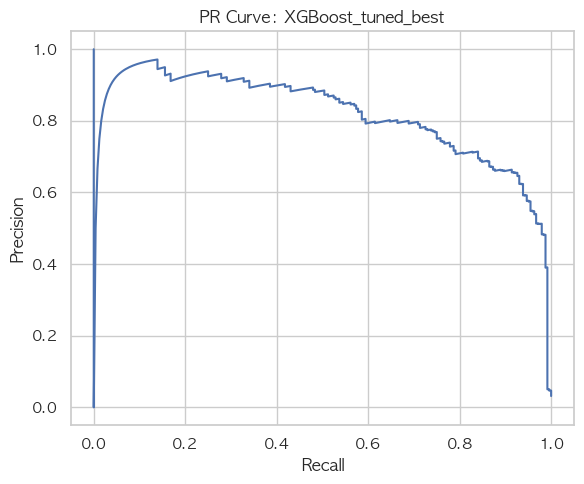

In [50]:
# Validation 기준 best XGBoost를 test set에서 최종 평가
valid_xgb_results = xgb_tuning_results.dropna(subset=['valid_pr_auc', 'valid_f1']).copy()
if len(valid_xgb_results) == 0:
    raise ValueError('성공한 XGBoost 튜닝 결과가 없습니다.')

best_idx = int(xgb_grid_search.best_index_)
best_xgb_params = xgb_grid_search.best_params_
best_xgb_row = xgb_tuning_results[xgb_tuning_results['candidate_id'].eq(best_idx)].iloc[0]
best_xgb_name = best_xgb_row['model']

# GridSearchCV의 refit 모델은 train+valid 전체로 재학습됩니다.
# validation threshold 누수를 피하기 위해 best params로 train set에만 다시 fit합니다.
best_xgb_model = XGBClassifier(
    **best_xgb_params,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)
best_xgb_model.fit(X_train_xgb, y_train_xgb)

best_xgb_valid_score = best_xgb_model.predict_proba(X_valid_xgb)[:, 1]
best_xgb_threshold = find_best_threshold(y_valid_xgb, best_xgb_valid_score)

best_xgb_test_score = best_xgb_model.predict_proba(X_test_xgb)[:, 1]
best_xgb_test_row = metric_row('XGBoost_tuned_best', y_test_xgb, best_xgb_test_score, best_xgb_threshold)
best_xgb_test_df = pd.DataFrame([best_xgb_test_row])

# 이후 셀과 호환되도록 best 모델 딕셔너리를 유지합니다.
xgb_tuned_models = {best_xgb_name: best_xgb_model, 'XGBoost_tuned_best': best_xgb_model}

print('Best GridSearchCV candidate index:', best_idx)
print('Best XGBoost candidate name:', best_xgb_name)
print('Best validation threshold:', best_xgb_threshold)
display(best_xgb_row.to_frame('best_candidate'))
display(best_xgb_test_df)

print('Best XGBoost params:')
for k, v in best_xgb_params.items():
    print(f'{k}: {v}')

best_xgb_test_df.to_csv(OUT_DIR / 'xgboost_tuned_best_test_report.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuned_best_test_report.csv')

best_xgb_pred = (best_xgb_test_score >= best_xgb_threshold).astype(int)
print(classification_report(y_test_xgb, best_xgb_pred, target_names=['양품', '불량'], zero_division=0))

cm = confusion_matrix(y_test_xgb, best_xgb_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['양품 예측','불량 예측'], yticklabels=['실제 양품','실제 불량'], ax=ax)
ax.set_title('Confusion Matrix: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_confusion_matrix.png', dpi=150)
plt.show()

precision, recall, _ = precision_recall_curve(y_test_xgb, best_xgb_test_score)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_pr_curve.png', dpi=150)
plt.show()


,feature,importance,gain,weight,cover
133,temp_mean,0.186352,548.873596,215.0,1607.441040
34,c2_temp_avg,0.111889,329.553345,124.0,1121.239624
25,dc1_temp_avg,0.058471,172.217072,167.0,1147.742554
27,c2_curr_end,0.041397,121.928902,916.0,726.795044
26,dc1_capafit,0.038163,112.402740,675.0,646.734863
131,m1_missing_flag,0.037089,109.240013,406.0,893.556030
132,all_missing_flag,0.035554,104.720352,189.0,1056.576538
43,c3_voltage_avg,0.021020,61.912544,387.0,289.593903
121,sa3_tat,0.017549,51.688572,648.0,412.897430
40,dc2_temp_avg,0.017440,51.365849,61.0,277.807343


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_importance.csv


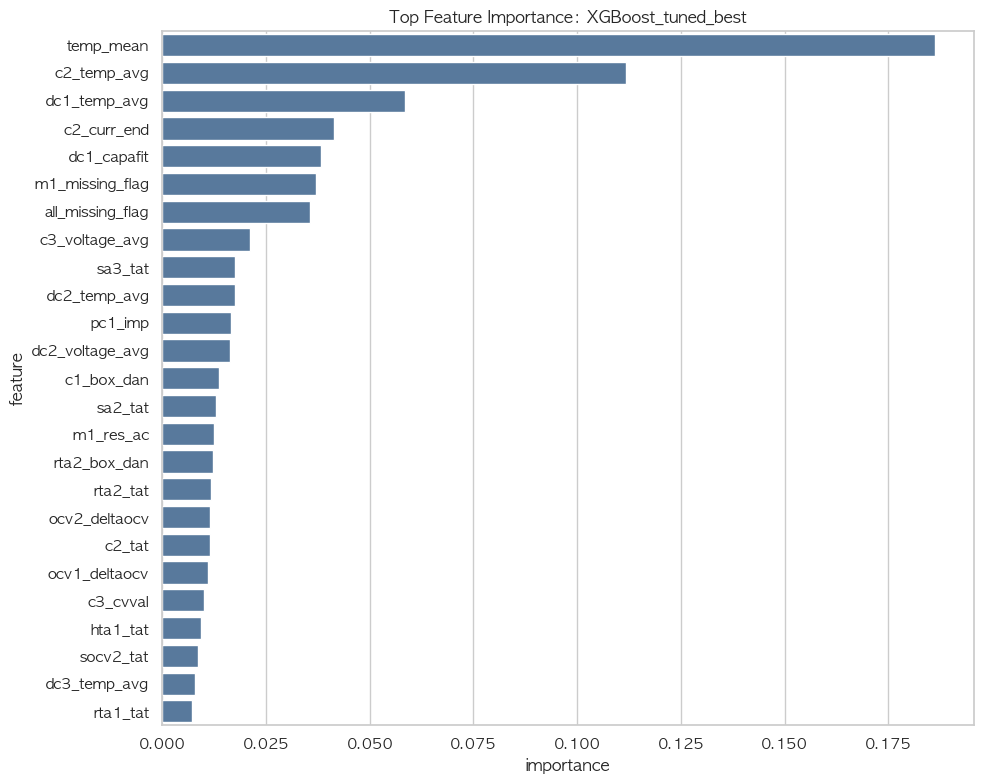

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_feature_importance.png


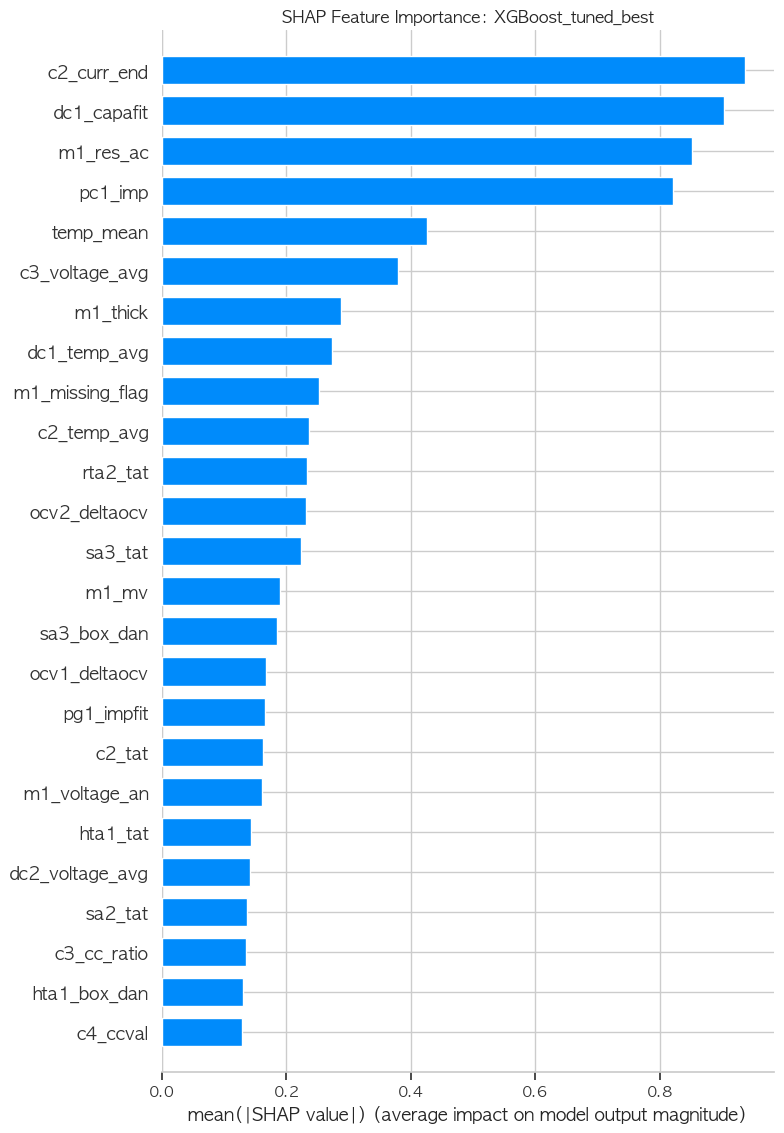

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_shap_bar.png


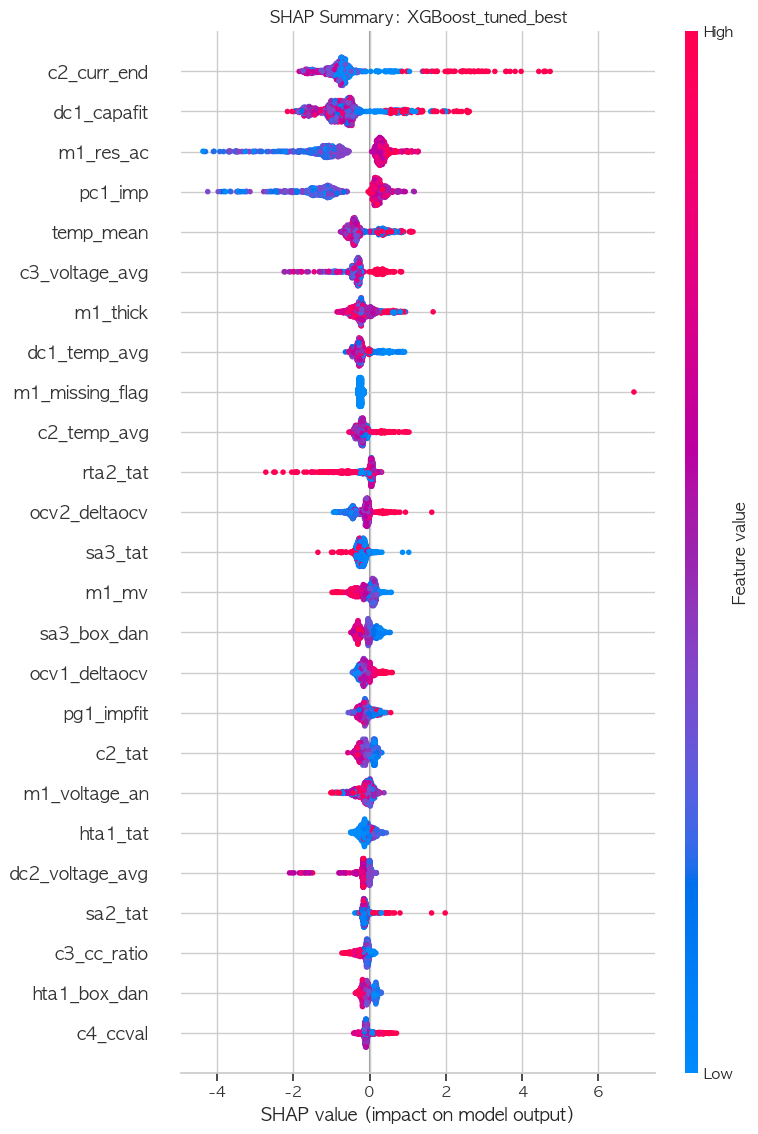

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_shap_summary.png


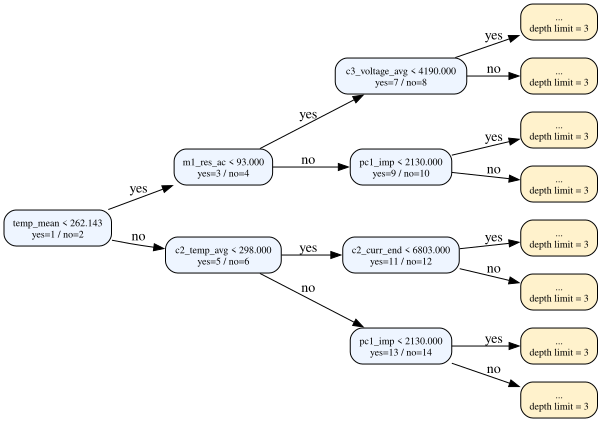

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_tree_0_depth3.png


In [51]:
# Best tuned XGBoost feature importance, SHAP, and tree visualization
best_xgb_importance = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': best_xgb_model.feature_importances_,
})

xgb_booster = best_xgb_model.get_booster()
for importance_type in ['gain', 'weight', 'cover']:
    score_map = xgb_booster.get_score(importance_type=importance_type)
    best_xgb_importance[importance_type] = [
        score_map.get(feature, score_map.get(f'f{i}', 0.0))
        for i, feature in enumerate(X_train_xgb.columns)
    ]

best_xgb_importance = best_xgb_importance.sort_values('importance', ascending=False)
display(best_xgb_importance.head(30))
best_xgb_importance.to_csv(OUT_DIR / 'xgboost_tuned_best_importance.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuned_best_importance.csv')

fig, ax = plt.subplots(figsize=(10, 8))
top_xgb_imp = best_xgb_importance.head(25).sort_values('importance', ascending=False)
sns.barplot(data=top_xgb_imp, x='importance', y='feature', ax=ax, color='#4C78A8', order=top_xgb_imp['feature'])
ax.set_title('Top Feature Importance: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_feature_importance.png', dpi=150)
plt.show()
print('saved:', OUT_DIR / 'xgboost_tuned_best_feature_importance.png')

# SHAP 시각화: 설치되어 있지 않으면 건너뜁니다.
if has_pkg('shap'):
    import shap
    shap_sample_n = min(1000, len(X_test_xgb))
    X_shap_xgb = X_test_xgb.sample(n=shap_sample_n, random_state=RANDOM_STATE) if len(X_test_xgb) > shap_sample_n else X_test_xgb.copy()
    xgb_explainer = shap.TreeExplainer(best_xgb_model)
    xgb_shap_values = xgb_explainer.shap_values(X_shap_xgb)
    if isinstance(xgb_shap_values, list):
        xgb_shap_values = xgb_shap_values[-1]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(xgb_shap_values, X_shap_xgb, plot_type='bar', show=False, max_display=25)
    plt.title('SHAP Feature Importance: XGBoost_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'xgboost_tuned_best_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'xgboost_tuned_best_shap_bar.png')

    plt.figure(figsize=(10, 8))
    shap.summary_plot(xgb_shap_values, X_shap_xgb, show=False, max_display=25)
    plt.title('SHAP Summary: XGBoost_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'xgboost_tuned_best_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'xgboost_tuned_best_shap_summary.png')
else:
    print('skip XGBoost SHAP: shap not installed')

# 발표용 XGBoost tree: 깊이를 제한해 저장합니다.
try:
    import json
    import shutil
    from graphviz import Digraph

    XGB_TREE_INDEX = 0
    XGB_MAX_DEPTH = 3
    tree_json = json.loads(best_xgb_model.get_booster().get_dump(dump_format='json')[XGB_TREE_INDEX])

    graph = Digraph()
    graph.attr(rankdir='LR')
    graph.attr('node', shape='box', style='rounded,filled', fillcolor='#EEF5FF', fontsize='10')

    def add_xgb_tree_node(node, depth=0, parent=None, edge_label=''):
        node_key = f"node_{node.get('nodeid', id(node))}_{depth}"
        if 'leaf' in node:
            label = f"Leaf\nvalue = {node['leaf']:.3f}"
            graph.node(node_key, label, fillcolor='#F7F7F7')
        elif depth >= XGB_MAX_DEPTH:
            label = f"...\ndepth limit = {XGB_MAX_DEPTH}"
            graph.node(node_key, label, fillcolor='#FFF2CC')
        else:
            label = f"{node['split']} < {node['split_condition']:.3f}\nyes={node.get('yes')} / no={node.get('no')}"
            graph.node(node_key, label)
            children = node.get('children', [])
            if len(children) >= 1:
                add_xgb_tree_node(children[0], depth + 1, node_key, 'yes')
            if len(children) >= 2:
                add_xgb_tree_node(children[1], depth + 1, node_key, 'no')
        if parent is not None:
            graph.edge(parent, node_key, edge_label)

    add_xgb_tree_node(tree_json)
    if shutil.which('dot') is None:
        print('skip XGBoost tree visualization: Graphviz executable "dot" is not installed or not on PATH')
        print('install hint: brew install graphviz')
    else:
        display(graph)
        xgb_tree_path = OUT_DIR / f'xgboost_tuned_best_tree_{XGB_TREE_INDEX}_depth{XGB_MAX_DEPTH}'
        graph.render(filename=str(xgb_tree_path), format='png', cleanup=True)
        print('saved:', f'{xgb_tree_path}.png')
except Exception as e:
    print('skip XGBoost tree visualization:', repr(e))


## 11. LightGBM 추가 해석용 SHAP

LightGBM은 최종 Best model로 사용하지 않지만, 비교/부록용으로 confusion matrix, importance에 이어 SHAP 시각화를 확인합니다.


In [52]:
# LightGBM additional SHAP visualization
if 'best_lgbm_model' not in globals():
    print('best_lgbm_model이 없습니다. LightGBM 튜닝/평가 셀을 먼저 실행하세요.')
elif not has_pkg('shap'):
    print('skip LightGBM SHAP: shap not installed')
else:
    import shap
    shap_sample_n = min(1000, len(X_test_lgbm))
    X_shap_lgbm = X_test_lgbm.sample(n=shap_sample_n, random_state=RANDOM_STATE) if len(X_test_lgbm) > shap_sample_n else X_test_lgbm.copy()
    lgbm_explainer = shap.TreeExplainer(best_lgbm_model)
    lgbm_shap_values = lgbm_explainer.shap_values(X_shap_lgbm)
    if isinstance(lgbm_shap_values, list):
        lgbm_shap_values = lgbm_shap_values[-1]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(lgbm_shap_values, X_shap_lgbm, plot_type='bar', show=False, max_display=25)
    plt.title('SHAP Feature Importance: LightGBM_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lightgbm_tuned_best_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'lightgbm_tuned_best_shap_bar.png')

    plt.figure(figsize=(10, 8))
    shap.summary_plot(lgbm_shap_values, X_shap_lgbm, show=False, max_display=25)
    plt.title('SHAP Summary: LightGBM_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lightgbm_tuned_best_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'lightgbm_tuned_best_shap_summary.png')


best_lgbm_model이 없습니다. LightGBM 튜닝/평가 셀을 먼저 실행하세요.


## 12. XGBoost 내장 Feature Importance 튜닝 전후 비교

튜닝 전 `XGBoost_weighted`와 튜닝 후 `XGBoost_tuned_best`를 같은 XGBoost 내장 `feature_importances_` 기준으로 비교합니다. 미리캔버스에 붙여넣기 쉽도록 상위 변수의 `feature`, `importance`만 TSV 형태로 출력하고 저장합니다.


In [53]:
# XGBoost built-in feature_importances_ comparison: before vs after tuning
top_n = 30

def _xgb_builtin_importance_df(model, feature_names):
    if model is None or not hasattr(model, 'feature_importances_'):
        return None
    importance_df = pd.DataFrame({
        'feature': list(feature_names),
        'importance': np.asarray(model.feature_importances_, dtype=float),
    })
    return importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

baseline_xgb_model = fitted_models.get('XGBoost_weighted') if 'fitted_models' in globals() else None
baseline_feature_names = get_matrix('tree').columns if 'get_matrix' in globals() else X_train_xgb.columns
tuned_feature_names = X_train_xgb.columns

xgb_builtin_before = _xgb_builtin_importance_df(baseline_xgb_model, baseline_feature_names)
xgb_builtin_after = _xgb_builtin_importance_df(best_xgb_model, tuned_feature_names)

if xgb_builtin_before is None:
    before_path = OUT_DIR / 'xgboost_weighted_importance.csv'
    if before_path.exists():
        xgb_builtin_before = pd.read_csv(before_path)[['feature', 'importance']].sort_values('importance', ascending=False).reset_index(drop=True)
    else:
        raise ValueError('튜닝 전 XGBoost_weighted 모델 또는 저장된 importance 파일을 찾을 수 없습니다.')

if xgb_builtin_after is None:
    after_path = OUT_DIR / 'xgboost_tuned_best_importance.csv'
    if after_path.exists():
        xgb_builtin_after = pd.read_csv(after_path)[['feature', 'importance']].sort_values('importance', ascending=False).reset_index(drop=True)
    else:
        raise ValueError('튜닝 후 best_xgb_model 또는 저장된 importance 파일을 찾을 수 없습니다.')

xgb_builtin_before.insert(0, 'stage', 'before_tuning')
xgb_builtin_after.insert(0, 'stage', 'after_tuning')
xgb_builtin_compare = pd.concat([xgb_builtin_before, xgb_builtin_after], ignore_index=True)

compare_path = OUT_DIR / 'xgboost_builtin_importance_before_after.csv'
before_tsv_path = OUT_DIR / 'xgboost_builtin_importance_before_miricanvas.tsv'
after_tsv_path = OUT_DIR / 'xgboost_builtin_importance_after_miricanvas.tsv'

xgb_builtin_compare.to_csv(compare_path, index=False, encoding='utf-8-sig')
xgb_builtin_before[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(before_tsv_path, sep='\t', index=False)
xgb_builtin_after[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(after_tsv_path, sep='\t', index=False)

print('saved:', compare_path)
print('saved:', before_tsv_path)
print('saved:', after_tsv_path)

print('\n[튜닝 전] XGBoost_weighted built-in feature_importances_ top', top_n)
print(xgb_builtin_before[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(sep='\t', index=False))

print('[튜닝 후] XGBoost_tuned_best built-in feature_importances_ top', top_n)
print(xgb_builtin_after[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(sep='\t', index=False))


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_builtin_importance_before_after.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_builtin_importance_before_miricanvas.tsv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_builtin_importance_after_miricanvas.tsv

[튜닝 전] XGBoost_weighted built-in feature_importances_ top 30
feature	importance
temp_mean	0.1681
c2_temp_avg	0.0805
dc1_temp_avg	0.0395
dc1_capafit	0.033
c2_curr_end	0.0307
dc2_temp_avg	0.0292
pc1_imp	0.0262
m1_missing_flag	0.024
dc1_box_dan	0.0213
all_missing_flag	0.0193
sa3_tat	0.0172
m1_res_ac	0.0168
c3_cvval	0.0161
rta2_tat	0.0154
c3_voltage_avg	0.015
c3_temp_avg	0.0139
sa2_tat	0.0135
ocv1_deltaocv	0.0124
socv2_tat	0.0123
ocv2_deltaocv	0.0108
weekday	0.0105
hta1_tat	0.0102
dc2_voltage_avg	0.0098
c3_capa	0.0089
c4_tat	0.0082
ocv1_box_dan	0.0079
dc2_voltage_band	0.0077
dc3_temp_avg	0.0077
sa3_box_dan	0.0074
pg1_temp_avg	0.0073

[튜닝 후] XGBoos